# 03. Local-fit 정책으로 field1+field2 학습 후보 라벨 검수 큐 만들기

이 노트북은 `02_label_policy_rebuild.ipynb`에서 확정한 정책을 실제 학습 후보 데이터인 `field1 + field2 raw`에 적용한다.

이번 노트북의 목적은 아직 최종 CULane 데이터셋을 만드는 것이 아니라, 먼저 다음 산출물을 만드는 것이다.

- `field1 + field2` 모든 raw 이미지에 local-fit lane ray 후보 생성
- 프레임별 `usable_auto / review_needed / reject` 상태 분류
- 검수용 overlay 이미지 저장
- 후보 라벨 manifest와 selected line CSV 저장

정책은 다음으로 고정한다.

```text
HSV: lower=[20, 140, 70], upper=[42, 255, 255]
Morphology: open3 -> close3
ROI: raw y >= 445
Label policy: local-fit ray
row representative: inner_edge
window_px: 120
max selected lines per frame: 2
```

중요한 해석:

- 이 라벨은 공식 CULane 원본처럼 전체 차선 곡선을 완벽히 복원하려는 라벨이 아니다.
- 우리 프로젝트에서는 CLRKDNet을 주행용 local direction detector로 적응시키는 것이 목적이다.
- 따라서 `.lines.txt`에 들어갈 후보는 “현재 프레임에서 차가 따라갈 수 있는 local lane ray”에 가깝다.


In [1]:
# 0. Imports and path setup
from pathlib import Path
from IPython.display import display, Image
import csv
import json
import math
import shutil
import time

import cv2
import numpy as np

try:
    import pandas as pd
except Exception as exc:
    raise RuntimeError('pandas가 필요합니다. <env> kernel에서 실행 중인지 확인하세요.') from exc

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '12_clrkdnet_supervised_rebuild'
NOTEBOOK_ROOT = EXP_ROOT / 'notebooks'
REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '03_review_q'
ASSET_LANE_ROOT = PROJECT_ROOT / '20_shared_assets' / 'dataset' / 'lane'
RAW_ROOT = ASSET_LANE_ROOT / 'raw'

FIELD1_RAW = RAW_ROOT / 'field1'
FIELD2_RAW = RAW_ROOT / 'field2'
FIELD3_RAW = RAW_ROOT / 'field3'

for p in [FIELD1_RAW, FIELD2_RAW]:
    print(p, 'exists=', p.exists())
    assert p.exists(), f'missing path: {p}'

REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
print(REVIEW_ROOT, 'exists=', REVIEW_ROOT.exists())
print('review root:', REVIEW_ROOT)


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\raw\field1 exists= True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\raw\field2 exists= True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q exists= True
review root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q


## 1. field1+field2 raw 입력 목록 만들기

여기서는 학습 후보로 사용할 원천 이미지를 먼저 고정한다.

- train candidate source: `20_shared_assets/dataset/lane/raw/field1`, `field2`
- holdout으로 남길 예정: `field3`

`field3`는 이 노트북에서 학습 후보로 쓰지 않는다. 02에서 정책 검증용으로 이미 사용했고, 이후 모델 평가/주행 시뮬레이션용 holdout으로 남기는 것이 목적이다.


In [2]:
# 1. Build input manifest for field1 + field2
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def list_images(root: Path, group: str):
    rows = []
    for p in sorted(root.rglob('*')):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            rows.append({
                'group': group,
                'abs_path': str(p),
                'rel_from_group': str(p.relative_to(root)),
                'rel': str(p.relative_to(RAW_ROOT)),
                'stem': p.stem,
            })
    return rows

input_rows = []
input_rows += list_images(FIELD1_RAW, 'field1')
input_rows += list_images(FIELD2_RAW, 'field2')
input_df = pd.DataFrame(input_rows)
print('input images:', len(input_df))
print(input_df.groupby('group').size())
display(input_df.head(10))

INPUT_MANIFEST_PATH = REVIEW_ROOT / 'field12_input_manifest.csv'
input_df.to_csv(INPUT_MANIFEST_PATH, index=False, encoding='utf-8-sig')
print('saved:', INPUT_MANIFEST_PATH)


input images: 9375
group
field1    4015
field2    5360
dtype: int64


,group,abs_path,rel_from_group,rel,stem
0,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160157_lane_none_in...,field1\lane\intersection\20260430_160157_lane_...,20260430_160157_lane_none_intersection_none_ce...
1,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
2,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
3,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
4,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
5,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
6,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160158_lane_none_in...,field1\lane\intersection\20260430_160158_lane_...,20260430_160158_lane_none_intersection_none_ce...
7,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160159_lane_none_in...,field1\lane\intersection\20260430_160159_lane_...,20260430_160159_lane_none_intersection_none_ce...
8,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160159_lane_none_in...,field1\lane\intersection\20260430_160159_lane_...,20260430_160159_lane_none_intersection_none_ce...
9,field1,~\02_Projects\University\26-1_Em...,lane\intersection\20260430_160159_lane_none_in...,field1\lane\intersection\20260430_160159_lane_...,20260430_160159_lane_none_intersection_none_ce...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q\field12_input_manifest.csv


## 2. 02에서 확정한 local-fit label 정책 구현

이 셀은 02 노트북에서 결정한 정책을 03 노트북 안에 고정해서 재현한다.

핵심 흐름은 다음과 같다.

```text
raw BGR image
→ ROI(y>=445)만 남김
→ HSV yellow mask
→ open3/close3
→ connected component 추출
→ 각 component의 아래쪽 local window 120px만 사용
→ row-wise inner edge를 대표 x로 선택
→ x = a*y + b 직선 fitting
→ sample_y에 맞춰 lane points 생성
→ 후보 중 최대 2개 선택
```

`inner_edge`는 lane 두께의 중앙이 아니라, 차량 중앙에 가까운 차선 경계 쪽을 대표값으로 삼겠다는 뜻이다. 이 프로젝트에서는 “노란 선 중심”보다 “주행 가능한 내부 경계/방향”을 학습시키는 것이 더 유리하다는 판단을 반영한다.


In [3]:
# 2. Local-fit label policy implementation
import hashlib
RAW_W = 1296
RAW_H = 972
CUT_HEIGHT = 445
MODEL_W = 800
MODEL_H = 320
SAMPLE_Y = list(range(971, 444, -20))
IMAGE_CENTER_X = RAW_W / 2.0

HSV_LOWER = np.array([20, 140, 70], dtype=np.uint8)
HSV_UPPER = np.array([42, 255, 255], dtype=np.uint8)
MORPH_OPS = [('open', 3), ('close', 3)]

POLICY = {
    'name': 'localfit_inner_edge_w120_h20_42_s140_v70_open3_close3',
    'row_mode': 'inner_edge',
    'window_px': 120,
    'max_lanes': 2,
    'min_component_area': 500,
    'min_local_pixels': 500,
    'min_row_count': 4,
    'min_local_y_span': 20,
    'duplicate_x_px': 80,
}

REVIEW_RULES = {
    'poor_fit_rms_th': 25.0,
    'poor_quality_th': 0.75,
    'weak_line_quality_th': 0.45,
    'weak_fit_rms_th': 40.0,
    'weak_sample_points_th': 8,
    'many_candidate_th': 3,
    'many_rejected_th': 3,
}


def imread_bgr(path: Path):
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def imwrite_image(path: Path, image):
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or '.jpg'
    ok, buf = cv2.imencode(ext, image)
    if not ok:
        raise RuntimeError(f'cv2.imencode failed: {path}')
    buf.tofile(str(path))


def safe_name_from_rel(rel: str, max_stem_len=54):
    # Keep overlay paths under the legacy Windows 260-char limit.
    # The manifest keeps the full original rel path; overlay filenames only need to be unique and readable.
    rel_norm = rel.replace('\\', '/')
    parts = rel_norm.split('/')
    group = parts[0] if parts else 'img'
    stem = Path(parts[-1]).stem if parts else Path(rel_norm).stem
    suffix = Path(parts[-1]).suffix.lower() if parts else '.jpg'
    if suffix not in ['.jpg', '.jpeg', '.png', '.bmp']:
        suffix = '.jpg'
    for ch in ':*?"<>| /\\':
        stem = stem.replace(ch, '_')
    digest = hashlib.md5(rel_norm.encode('utf-8')).hexdigest()[:8]
    return f'{group}_{digest}_{stem[:max_stem_len]}{suffix}'

GROUP_SHORT = {'field1': 'f1', 'field2': 'f2', 'field3': 'f3'}
CATEGORY_SHORT = {
    'no_line': 'no',
    'single_lane': 'single',
    'weak_line': 'weak',
    'many_candidates': 'many',
    'many_rejected': 'rejmany',
    'poor_fit': 'poor',
    'clean_pair': 'clean',
}


def make_yellow_mask_full(bgr):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, HSV_LOWER, HSV_UPPER)
    roi = np.zeros_like(mask)
    roi[CUT_HEIGHT:, :] = mask[CUT_HEIGHT:, :]
    mask = roi
    for op, k in MORPH_OPS:
        kernel = np.ones((k, k), np.uint8)
        if op == 'open':
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        elif op == 'close':
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        else:
            raise ValueError(op)
    return mask


def x_at_y(line, y):
    return float(line['a'] * y + line['b'])


def fit_line_x_as_function_of_y(ys, xs):
    ys = np.asarray(ys, dtype=np.float64)
    xs = np.asarray(xs, dtype=np.float64)
    if len(xs) < 2:
        return None
    a, b = np.polyfit(ys, xs, 1)
    pred = a * ys + b
    rms = float(np.sqrt(np.mean((xs - pred) ** 2)))
    return float(a), float(b), rms


def line_points_from_fit(a, b):
    pts = []
    for y in SAMPLE_Y:
        x = a * y + b
        if 0 <= x < RAW_W:
            pts.append((float(x), float(y)))
    return pts


def format_points_preview(points, max_points=8):
    vals = []
    for x, y in points[:max_points]:
        vals.append(f'{x:.1f} {int(round(y))}')
    return ' '.join(vals)


def component_candidates(mask, policy=POLICY):
    num, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    candidates = []
    rejected = []

    for label_id in range(1, num):
        x, y, w, h, area = stats[label_id]
        cx, cy = centroids[label_id]
        record_base = {
            'label_id': int(label_id),
            'component_area': int(area),
            'x_min': int(x),
            'x_max': int(x + w - 1),
            'y_min': int(y),
            'y_max': int(y + h - 1),
            'centroid_x': float(cx),
            'centroid_y': float(cy),
        }
        if area < policy['min_component_area']:
            rejected.append({**record_base, 'reject_reason': 'small_component_area'})
            continue

        ys_all, xs_all = np.where(labels == label_id)
        local_y_max = int(ys_all.max())
        local_y_min = max(CUT_HEIGHT, local_y_max - int(policy['window_px']))
        keep = ys_all >= local_y_min
        local_ys = ys_all[keep]
        local_xs = xs_all[keep]
        local_pixels = int(len(local_xs))
        local_y_span = int(local_ys.max() - local_ys.min()) if local_pixels else 0
        if local_pixels < policy['min_local_pixels']:
            rejected.append({**record_base, 'reject_reason': 'low_local_pixels', 'local_pixels': local_pixels, 'local_y_span': local_y_span})
            continue
        if local_y_span < policy['min_local_y_span']:
            rejected.append({**record_base, 'reject_reason': 'short_local_y_span', 'local_pixels': local_pixels, 'local_y_span': local_y_span})
            continue

        row_x = []
        row_y = []
        is_left_component = float(np.mean(local_xs)) < IMAGE_CENTER_X
        for yy in sorted(np.unique(local_ys)):
            xs = local_xs[local_ys == yy]
            if len(xs) == 0:
                continue
            if policy['row_mode'] == 'center':
                rep = float(np.median(xs))
            elif policy['row_mode'] == 'inner_edge':
                rep = float(np.quantile(xs, 0.90 if is_left_component else 0.10))
            elif policy['row_mode'] == 'outer_edge':
                rep = float(np.quantile(xs, 0.10 if is_left_component else 0.90))
            else:
                raise ValueError(policy['row_mode'])
            row_x.append(rep)
            row_y.append(float(yy))

        row_center_count = len(row_x)
        if row_center_count < policy['min_row_count']:
            rejected.append({**record_base, 'reject_reason': 'low_row_count', 'row_center_count': row_center_count, 'local_pixels': local_pixels, 'local_y_span': local_y_span})
            continue

        fit = fit_line_x_as_function_of_y(row_y, row_x)
        if fit is None:
            rejected.append({**record_base, 'reject_reason': 'fit_failed', 'row_center_count': row_center_count, 'local_pixels': local_pixels, 'local_y_span': local_y_span})
            continue
        a, b, fit_rms = fit
        points = line_points_from_fit(a, b)
        sample_point_count = len(points)

        if sample_point_count < 2:
            rejected.append({**record_base, 'reject_reason': 'too_few_sample_points', 'sample_point_count': sample_point_count, 'row_center_count': row_center_count, 'local_pixels': local_pixels, 'local_y_span': local_y_span, 'fit_rms_px': fit_rms})
            continue

        span_score = min(1.0, local_y_span / max(1.0, float(policy['window_px'])))
        row_score = min(1.0, row_center_count / 24.0)
        rms_score = max(0.0, 1.0 - fit_rms / 80.0)
        points_score = min(1.0, sample_point_count / 12.0)
        line_quality = float(0.35 * span_score + 0.25 * row_score + 0.25 * rms_score + 0.15 * points_score)

        x_dup_y = x_at_y({'a': a, 'b': b}, 851)
        candidate = {
            **record_base,
            'policy': policy['name'],
            'row_mode': policy['row_mode'],
            'window_px': int(policy['window_px']),
            'a': a,
            'b': b,
            'fit_rms_px': fit_rms,
            'local_pixels': local_pixels,
            'local_y_span': local_y_span,
            'local_y_min': int(local_y_min),
            'local_y_max': int(local_y_max),
            'local_centroid_x': float(np.mean(local_xs)),
            'local_centroid_y': float(np.mean(local_ys)),
            'row_center_count': int(row_center_count),
            'fit_input': 'inner_edge_quantile_row_rep',
            'sample_point_count': int(sample_point_count),
            'sample_points': points,
            'sample_points_preview': format_points_preview(points),
            'line_quality': line_quality,
            'x_at_dup_y': float(x_dup_y),
            'is_weak_line': bool(
                line_quality < REVIEW_RULES['weak_line_quality_th'] or
                fit_rms > REVIEW_RULES['weak_fit_rms_th'] or
                sample_point_count < REVIEW_RULES['weak_sample_points_th']
            ),
        }
        candidates.append(candidate)

    return candidates, rejected


def select_policy_lines(candidates, policy=POLICY):
    ordered = sorted(
        candidates,
        key=lambda r: (
            -float(r['line_quality']),
            -int(r['local_pixels']),
            abs(float(r['local_centroid_x']) - IMAGE_CENTER_X),
        )
    )
    selected = []
    duplicate_skipped = []
    for cand in ordered:
        x = float(cand['x_at_dup_y'])
        duplicate = False
        for sel in selected:
            if abs(x - float(sel['x_at_dup_y'])) < policy['duplicate_x_px']:
                duplicate = True
                break
        if duplicate:
            duplicate_skipped.append(cand)
            continue
        selected.append(cand)
        if len(selected) >= policy['max_lanes']:
            break
    return selected, duplicate_skipped, ordered


def draw_overlay(bgr, mask, selected, candidates=None, rejected=None, title=''):
    out = bgr.copy()
    green = np.zeros_like(out)
    green[:, :, 1] = 255
    mask_bool = mask > 0
    # Boolean-indexed arrays are not always accepted by cv2.addWeighted on Windows builds.
    # Blend directly with numpy so overlay generation is deterministic.
    out[mask_bool] = (
        out[mask_bool].astype(np.float32) * 0.58 +
        green[mask_bool].astype(np.float32) * 0.42
    ).astype(np.uint8)

    cv2.line(out, (0, CUT_HEIGHT), (RAW_W - 1, CUT_HEIGHT), (0, 0, 255), 2)
    cv2.line(out, (0, 851), (RAW_W - 1, 851), (255, 255, 0), 1)
    cv2.line(out, (int(IMAGE_CENTER_X), CUT_HEIGHT), (int(IMAGE_CENTER_X), RAW_H - 1), (230, 230, 230), 1)

    if candidates:
        for cand in candidates:
            x1, x2 = int(cand['x_min']), int(cand['x_max'])
            y1, y2 = int(cand['local_y_min']), int(cand['local_y_max'])
            cv2.rectangle(out, (x1, y1), (x2, y2), (80, 80, 80), 1)

    colors = [(0, 255, 255), (255, 0, 255)]
    for idx, line in enumerate(selected):
        color = colors[idx % len(colors)]
        pts = [(int(round(x)), int(round(y))) for x, y in line['sample_points'] if 0 <= x < RAW_W and 0 <= y < RAW_H]
        if len(pts) >= 2:
            for p1, p2 in zip(pts[:-1], pts[1:]):
                cv2.line(out, p1, p2, color, 3)
            cv2.circle(out, pts[0], 5, color, -1)
        text = f"line{idx+1}: q={line['line_quality']:.2f} rms={line['fit_rms_px']:.1f} pts={line['sample_point_count']}"
        cv2.putText(out, text, (12, 28 + idx * 28), cv2.FONT_HERSHEY_SIMPLEX, 0.72, color, 2, cv2.LINE_AA)

    if title:
        cv2.putText(out, title[:90], (12, RAW_H - 18), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 2, cv2.LINE_AA)
    return out


def make_sheet(image_paths, out_path, max_cols=4, thumb_w=360):
    imgs = []
    for p in image_paths:
        im = imread_bgr(Path(p))
        if im is None:
            continue
        h, w = im.shape[:2]
        thumb_h = int(round(h * thumb_w / w))
        im = cv2.resize(im, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)
        imgs.append(im)
    if not imgs:
        return None
    rows = []
    for i in range(0, len(imgs), max_cols):
        row = imgs[i:i + max_cols]
        max_h = max(im.shape[0] for im in row)
        padded = []
        for im in row:
            if im.shape[0] < max_h:
                pad = np.zeros((max_h - im.shape[0], im.shape[1], 3), dtype=np.uint8)
                im = np.vstack([im, pad])
            padded.append(im)
        while len(padded) < max_cols:
            padded.append(np.zeros((max_h, thumb_w, 3), dtype=np.uint8))
        rows.append(np.hstack(padded))
    sheet = np.vstack(rows)
    imwrite_image(out_path, sheet)
    return out_path

print('policy:', json.dumps(POLICY, ensure_ascii=False, indent=2))
print('review rules:', json.dumps(REVIEW_RULES, ensure_ascii=False, indent=2))


policy: {
  "name": "localfit_inner_edge_w120_h20_42_s140_v70_open3_close3",
  "row_mode": "inner_edge",
  "window_px": 120,
  "max_lanes": 2,
  "min_component_area": 500,
  "min_local_pixels": 500,
  "min_row_count": 4,
  "min_local_y_span": 20,
  "duplicate_x_px": 80
}
review rules: {
  "poor_fit_rms_th": 25.0,
  "poor_quality_th": 0.75,
  "weak_line_quality_th": 0.45,
  "weak_fit_rms_th": 40.0,
  "weak_sample_points_th": 8,
  "many_candidate_th": 3,
  "many_rejected_th": 3
}


## 3. 전체 field1+field2 라벨 후보 생성 + 검수 폴더 분류

이 셀은 약 9천 장 전체에 대해 라벨 후보와 검수 큐를 만든다.

이번 수정 기준에서는 `many_candidates`, `many_rejected`, `single_lane`을 더 이상 자동 검수 대상으로 보내지 않는다. 이 값들은 manifest에 진단용 metadata로만 남긴다.

검수 폴더로 보내는 기준은 실제로 라벨 품질이 위험할 때만 사용한다.

```text
reject:
- selected_count == 0

review_needed:
- weak_line_count >= 1
- worst_fit_rms_px > 25
- min_line_quality < 0.75

usable_auto:
- selected_count >= 1
- 위 review 조건에 걸리지 않음
```

즉, 후보가 많거나 중간에 버려진 component가 많다는 이유만으로는 검수 대상으로 보내지 않는다. 최종 선택된 ray가 주행용 라벨로 충분하면 학습 후보로 둔다.


In [4]:
# 3. Full field1+field2 candidate build and review queue export
RUN_FULL_BUILD = True
SAVE_ALL_REVIEW_OVERLAYS = True
SAVE_ALL_REJECT_OVERLAYS = True
SAVE_USABLE_AUTO_SAMPLE = True
USABLE_AUTO_SAMPLE_EVERY = 80
USABLE_AUTO_SAMPLE_MAX_PER_GROUP = 120

if not RUN_FULL_BUILD:
    raise RuntimeError('Set RUN_FULL_BUILD=True when you are ready to build the review queue.')

OVERLAY_ROOT = REVIEW_ROOT / '_ov'
if OVERLAY_ROOT.exists():
    shutil.rmtree(OVERLAY_ROOT)
OVERLAY_ROOT.mkdir(parents=True, exist_ok=True)

manifest_rows = []
line_rows = []
start = time.time()
usable_sample_counts = {'field1': 0, 'field2': 0}

for idx, row in input_df.iterrows():
    if idx % 250 == 0:
        elapsed = time.time() - start
        print(f'[{idx}/{len(input_df)}] elapsed_min={elapsed/60:.1f}')

    p = Path(row['abs_path'])
    bgr = imread_bgr(p)
    if bgr is None:
        manifest_rows.append({**row, 'status': 'reject', 'review_category': 'read_failed', 'selected_count': 0, 'candidate_count': 0, 'rejected_count': 0, 'weak_line_count': 0})
        continue

    mask = make_yellow_mask_full(bgr)
    candidates, rejected = component_candidates(mask)
    selected, duplicate_skipped, ordered = select_policy_lines(candidates)

    selected_count = len(selected)
    candidate_count = len(candidates)
    rejected_count = len(rejected)
    weak_line_count = sum(1 for s in selected if s['is_weak_line'])
    best_fit_rms = min([s['fit_rms_px'] for s in selected], default=None)
    worst_fit_rms = max([s['fit_rms_px'] for s in selected], default=None)
    best_quality = max([s['line_quality'] for s in selected], default=None)
    min_quality = min([s['line_quality'] for s in selected], default=None)

    review_flags = []
    diagnostic_flags = []
    if selected_count == 1:
        diagnostic_flags.append('single_lane')
    if candidate_count >= REVIEW_RULES['many_candidate_th']:
        diagnostic_flags.append('many_candidates')
    if rejected_count >= REVIEW_RULES['many_rejected_th']:
        diagnostic_flags.append('many_rejected')

    if selected_count == 0:
        status = 'reject'
        review_category = 'no_line'
        review_flags.append('selected0')
    else:
        if weak_line_count >= 1:
            review_flags.append('weak_line')
        if worst_fit_rms is not None and worst_fit_rms > REVIEW_RULES['poor_fit_rms_th']:
            review_flags.append('poor_fit_rms')
        if min_quality is not None and min_quality < REVIEW_RULES['poor_quality_th']:
            review_flags.append('poor_quality')

        if review_flags:
            status = 'review_needed'
            # 검수 폴더는 실제 라벨 품질 위험만 기준으로 나눈다.
            if 'weak_line' in review_flags:
                review_category = 'weak_line'
            else:
                review_category = 'poor_fit'
        else:
            status = 'usable_auto'
            review_category = 'clean_pair'

    overlay_rel = ''
    save_overlay = False
    if status == 'reject' and SAVE_ALL_REJECT_OVERLAYS:
        save_overlay = True
        overlay_dir = OVERLAY_ROOT / 'r' / CATEGORY_SHORT.get(review_category, review_category[:8]) / GROUP_SHORT.get(row['group'], row['group'])
    elif status == 'review_needed' and SAVE_ALL_REVIEW_OVERLAYS:
        save_overlay = True
        overlay_dir = OVERLAY_ROOT / 'rv' / CATEGORY_SHORT.get(review_category, review_category[:8]) / GROUP_SHORT.get(row['group'], row['group'])
    elif status == 'usable_auto' and SAVE_USABLE_AUTO_SAMPLE:
        if usable_sample_counts[row['group']] < USABLE_AUTO_SAMPLE_MAX_PER_GROUP and idx % USABLE_AUTO_SAMPLE_EVERY == 0:
            save_overlay = True
            usable_sample_counts[row['group']] += 1
            overlay_dir = OVERLAY_ROOT / 'auto' / GROUP_SHORT.get(row['group'], row['group'])

    if save_overlay:
        title = f"{status}/{review_category} | sel={selected_count} cand={candidate_count} rej={rejected_count} weak={weak_line_count} | {Path(row['rel']).name}"
        overlay = draw_overlay(bgr, mask, selected, candidates=ordered, rejected=rejected, title=title)
        overlay_path = overlay_dir / safe_name_from_rel(row['rel'])
        imwrite_image(overlay_path, overlay)
        overlay_rel = str(overlay_path.relative_to(REVIEW_ROOT))

    manifest_row = {
        **row,
        'policy': POLICY['name'],
        'status': status,
        'review_category': review_category,
        'review_flags': ','.join(review_flags),
        'diagnostic_flags': ','.join(diagnostic_flags),
        'selected_count': selected_count,
        'candidate_count': candidate_count,
        'rejected_count': rejected_count,
        'duplicate_skipped_count': len(duplicate_skipped),
        'weak_line_count': weak_line_count,
        'best_fit_rms_px': best_fit_rms,
        'worst_fit_rms_px': worst_fit_rms,
        'best_line_quality': best_quality,
        'min_line_quality': min_quality,
        'overlay_rel': overlay_rel,
    }
    manifest_rows.append(manifest_row)

    for lane_idx, line in enumerate(selected):
        line_row = {k: v for k, v in line.items() if k != 'sample_points'}
        line_row.update({
            'group': row['group'],
            'rel': row['rel'],
            'frame_status': status,
            'review_category': review_category,
            'review_flags': ','.join(review_flags),
            'diagnostic_flags': ','.join(diagnostic_flags),
            'lane_idx': lane_idx,
            'points_text': ' '.join([f'{x:.1f} {y:.0f}' for x, y in line['sample_points']]),
        })
        line_rows.append(line_row)

manifest_df = pd.DataFrame(manifest_rows)
lines_df = pd.DataFrame(line_rows)

manifest_path = REVIEW_ROOT / 'label_candidate_manifest_field12.csv'
lines_path = REVIEW_ROOT / 'selected_lines_field12.csv'
manifest_df.to_csv(manifest_path, index=False, encoding='utf-8-sig')
lines_df.to_csv(lines_path, index=False, encoding='utf-8-sig')

def json_count_dict(series):
    return {str(k): int(v) for k, v in series.items()}

status_by_group = {
    f'{str(group)}::{str(status)}': int(count)
    for (group, status), count in manifest_df.groupby(['group', 'status']).size().items()
}

summary = {
    'policy': POLICY,
    'review_rules': REVIEW_RULES,
    'input_count': int(len(input_df)),
    'manifest': str(manifest_path),
    'selected_lines': str(lines_path),
    'status_counts': json_count_dict(manifest_df['status'].value_counts()),
    'status_by_group': status_by_group,
    'review_category_counts': json_count_dict(manifest_df['review_category'].value_counts()),
    'review_flag_counts': json_count_dict(manifest_df['review_flags'].replace('', 'none').value_counts()),
    'diagnostic_flag_counts': json_count_dict(manifest_df['diagnostic_flags'].replace('', 'none').value_counts()),
    'selected_count_counts': json_count_dict(manifest_df['selected_count'].value_counts().sort_index()),
    'elapsed_min': float((time.time() - start) / 60.0),
}
summary_path = REVIEW_ROOT / 'build_review_summary.json'
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print('saved manifest:', manifest_path)
print('saved lines:', lines_path)
print('saved summary:', summary_path)
print(json.dumps(summary, ensure_ascii=False, indent=2)[:4000])
display(manifest_df.groupby(['group', 'status']).size().reset_index(name='count'))
display(manifest_df.groupby(['status', 'review_category']).size().reset_index(name='count').sort_values(['status', 'count'], ascending=[True, False]))


[0/9375] elapsed_min=0.0
[250/9375] elapsed_min=0.2
[500/9375] elapsed_min=0.3
[750/9375] elapsed_min=0.5
[1000/9375] elapsed_min=0.6
[1250/9375] elapsed_min=0.8
[1500/9375] elapsed_min=1.0
[1750/9375] elapsed_min=1.1
[2000/9375] elapsed_min=1.2
[2250/9375] elapsed_min=1.4
[2500/9375] elapsed_min=1.6
[2750/9375] elapsed_min=1.7
[3000/9375] elapsed_min=1.9
[3250/9375] elapsed_min=2.0
[3500/9375] elapsed_min=2.2
[3750/9375] elapsed_min=2.3
[4000/9375] elapsed_min=2.5
[4250/9375] elapsed_min=2.6
[4500/9375] elapsed_min=2.8
[4750/9375] elapsed_min=2.9
[5000/9375] elapsed_min=3.1
[5250/9375] elapsed_min=3.3
[5500/9375] elapsed_min=3.4
[5750/9375] elapsed_min=3.5
[6000/9375] elapsed_min=3.7
[6250/9375] elapsed_min=3.8
[6500/9375] elapsed_min=4.0
[6750/9375] elapsed_min=4.1
[7000/9375] elapsed_min=4.3
[7250/9375] elapsed_min=4.4
[7500/9375] elapsed_min=4.6
[7750/9375] elapsed_min=4.7
[8000/9375] elapsed_min=4.8
[8250/9375] elapsed_min=5.0
[8500/9375] elapsed_min=5.1
[8750/9375] elapsed_min=5.

,group,status,count
0,field1,reject,1
1,field1,review_needed,321
2,field1,usable_auto,3693
3,field2,reject,31
4,field2,review_needed,406
5,field2,usable_auto,4923


,status,review_category,count
0,reject,no_line,32
2,review_needed,weak_line,393
1,review_needed,poor_fit,334
3,usable_auto,clean_pair,8616


## 4. 검수할 폴더 확인

전체 빌드가 끝나면 아래 폴더를 보면 된다.

```text
_ov/r/no/        # selected_count == 0, 학습 제외
_ov/rv/weak/     # weak line 포함
_ov/rv/poor/     # fit/quality 기준 위험
_ov/auto/        # 자동 통과 샘플
```

`single_lane`, `many_candidates`, `many_rejected`는 이제 검수 폴더 기준이 아니라 manifest의 진단용 column으로만 남긴다. 필요하면 나중에 CSV에서 필터링할 수 있다.


review root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q
overlay root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q\_ov

folder tree:
_ov\auto\f1 : 46
_ov\auto\f2 : 60
_ov\r\no\f1 : 1
_ov\r\no\f2 : 31
_ov\rv\poor\f1 : 83
_ov\rv\poor\f2 : 251
_ov\rv\weak\f1 : 238
_ov\rv\weak\f2 : 155
sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q\review_sheets\reject_no_line_sheet.jpg
sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q\review_sheets\review_weak_line_sheet.jpg
sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\03_review_q\revi

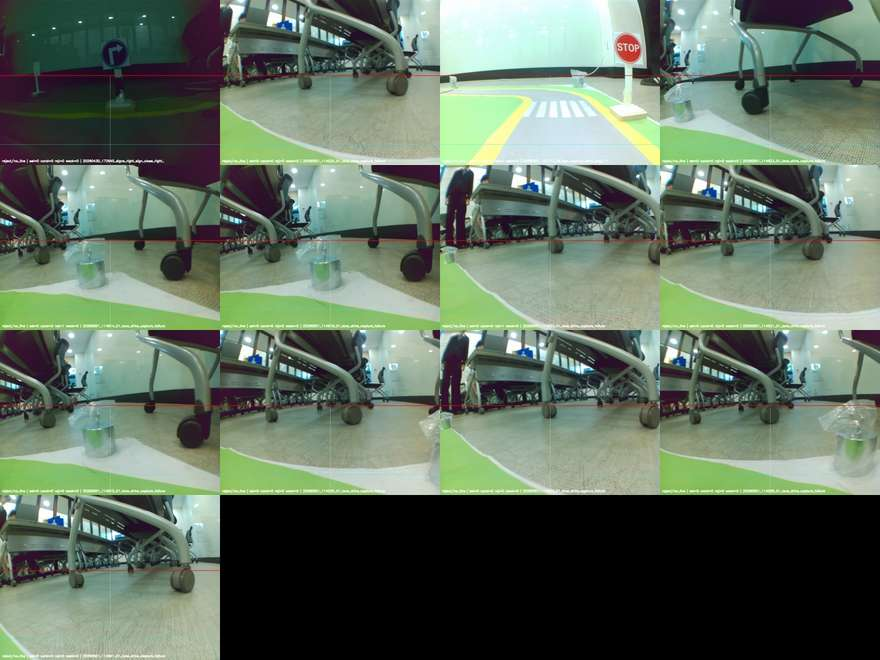


manifest status counts


,status,count
0,usable_auto,8616
1,review_needed,727
2,reject,32



review category counts


,review_category,count
0,clean_pair,8616
1,weak_line,393
2,poor_fit,334
3,no_line,32



diagnostic flag counts


,diagnostic_flags,count
0,"many_candidates,many_rejected",3187
1,many_rejected,2406
2,none,1960
3,many_candidates,1140
4,single_lane,497
5,"single_lane,many_rejected",185


In [6]:
# 4. Print review folders and samples
if 'manifest_df' not in globals():
    manifest_path = REVIEW_ROOT / 'label_candidate_manifest_field12.csv'
    manifest_df = pd.read_csv(manifest_path)

OVERLAY_ROOT = REVIEW_ROOT / '_ov'
print('review root:', REVIEW_ROOT)
print('overlay root:', OVERLAY_ROOT)
print('\nfolder tree:')
if OVERLAY_ROOT.exists():
    for p in sorted(OVERLAY_ROOT.rglob('*')):
        if p.is_dir():
            count = sum(1 for x in p.iterdir() if x.is_file() and x.suffix.lower() in IMAGE_EXTS)
            if count:
                print(f'{p.relative_to(REVIEW_ROOT)} : {count}')
else:
    print('overlay root does not exist yet. Run section 3 first.')

# Make small sheets for fast visual entry points.
sheet_dir = REVIEW_ROOT / 'review_sheets'
sheet_dir.mkdir(parents=True, exist_ok=True)
created_sheets = []
sheet_specs = [
    ('reject_no_line', OVERLAY_ROOT / 'r' / 'no'),
    ('review_weak_line', OVERLAY_ROOT / 'rv' / 'weak'),
    ('review_poor_fit', OVERLAY_ROOT / 'rv' / 'poor'),
    ('usable_auto_sample', OVERLAY_ROOT / 'auto'),
]
for name, base in sheet_specs:
    if not base.exists():
        continue
    paths = []
    for r in sorted([x for x in base.rglob('*') if x.is_dir()]):
        paths.extend(sorted(r.glob('*.jpg'))[:12])
    if not paths:
        paths = sorted(base.glob('*.jpg'))[:24]
    if not paths:
        continue
    out = sheet_dir / f'{name}_sheet.jpg'
    make_sheet(paths[:24], out, max_cols=4, thumb_w=360)
    created_sheets.append(out)
    print('sheet:', out)

if created_sheets:
    display(Image(filename=str(created_sheets[0])))

print('\nmanifest status counts')
display(manifest_df['status'].value_counts().rename_axis('status').reset_index(name='count'))
print('\nreview category counts')
display(manifest_df['review_category'].value_counts().rename_axis('review_category').reset_index(name='count'))
if 'diagnostic_flags' in manifest_df.columns:
    print('\ndiagnostic flag counts')
    display(manifest_df['diagnostic_flags'].replace('', 'none').value_counts().rename_axis('diagnostic_flags').reset_index(name='count'))


## 5. 이 노트북의 종료 기준

이 노트북은 다음 파일들이 생성되면 역할을 마친다.

```text
label_candidate_manifest_field12.csv
selected_lines_field12.csv
build_review_summary.json
_review_overlays/
```

이후 사람이 할 일은 `review_needed` 폴더를 보고, 명백히 학습에 넣으면 안 되는 이미지 파일명만 blacklist로 정리하는 것이다.

다음 단계는 별도 노트북에서 진행한다.

```text
04_build_final_culane_dataset_v1.ipynb
- blacklist 반영
- field1+field2 train dataset 생성
- field3 holdout dataset 생성
- CULane list/train_gt.txt, val.txt, test.txt 생성
- validation_summary.json 생성
```
